# Многоспутниковый эксперимент привязки траектории

Этот ноутбук реализует пакетный эксперимент привязки для шести эталонных спутников. Событие слежения - только удобный способ выбрать последовательные исторические записи телеметрии; сама функция потерь использует невязки состояния GCRS в выбранные эпохи и динамическую согласованность между этими эпохами.

Вместо отдельной подгонки массы, площади, Cd и Cr оптимизация ниже работает с баллистическими коэффициентами, которые непосредственно входят в уравнения сил: `Cd*A/m` для сопротивления и `Cr*A/m` для SRP / давления излучения Земли.

In [1]:
import os
import sys
import subprocess
from pathlib import Path

IN_COLAB = 'google.colab' in sys.modules
REPO_URL = 'https://github.com/Gavr101/space_modeling.git'


def run(cmd):
    print('>>', ' '.join(map(str, cmd)))
    subprocess.check_call(cmd)


def find_project_root(start):
    start = Path(start).resolve()
    for candidate in (start, *start.parents):
        if (candidate / 'dynamics').is_dir() and (candidate / 'visualization').is_dir():
            return candidate
    raise RuntimeError(f'Cannot find project root from {start}')


if IN_COLAB:
    PROJECT_ROOT = Path('/content/space_modeling')
    if not PROJECT_ROOT.exists():
        run(['git', 'clone', REPO_URL, str(PROJECT_ROOT)])
    os.chdir(PROJECT_ROOT)
    run([sys.executable, '-m', 'pip', 'install', '--upgrade', 'pip'])
    run([sys.executable, '-m', 'pip', 'install', '-r', 'requirements.txt'])
    run([sys.executable, '-m', 'pip', 'install', '-e', '.'])
else:
    PROJECT_ROOT = find_project_root(Path.cwd())
    os.chdir(PROJECT_ROOT)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print('Working dir:', PROJECT_ROOT)

Working dir: C:\Users\Gavriil\VS_projects\space_modeling


In [2]:
import matplotlib.pyplot as plt
import numpy as np
from astropy import units as u
from astropy.coordinates import GCRS, ITRS, CartesianRepresentation
from scipy.optimize import least_squares

from dynamics.eof import read_sentinel_eof
from dynamics.force_models import ForceModelConfig
from dynamics.propagator import PropagationConfig, SpacecraftProperties, propagate_orbit
from dynamics.sp3 import download_sp3, itrs_states_to_gcrs, read_sp3, sp3_velocity_records

## Конфигурация эксперимента

Силовая модель повторяет `prediction_error_growth_demo.ipynb`: включены J2, сопротивление, третьи тела Солнце/Луна и SRP. Веса измерений ниже являются ковариационными допущениями для целевой функции least-squares, а не случайными возмущениями исторических состояний.

In [3]:
EARTH_RADIUS_M = 6_378_137.0
EARTH_MU_M3_S2 = 3.986004418e14
DATA_DIR = PROJECT_ROOT / 'data'

CROSSING_MODE = 'latitude'  # 'latitude' or 'longitude'
TARGET_LATITUDE_DEG = 67.5641
TARGET_LONGITUDE_DEG = 67.5641
CROSSING_DIRECTION = 'ascending'  # Same direction gives roughly one orbit between consecutive crossings.
N_MEASUREMENTS = 2
LAST_CROSSING_AFTER_H = 6.0
ORBIT_PERIOD_REL_TOL = 0.25

FORECAST_HOURS = 12.0
PROPAGATION_STEP_SECONDS = 120.0
REFERENCE_DURATION_HOURS = LAST_CROSSING_AFTER_H + FORECAST_HOURS + 4.0

# Эти сигмы являются ковариационными допущениями для исторических измерений, а не случайным шумом.
# Последнее измерение задаёт t = 0 и закрепляется жёстче, чтобы избежать большой
# невязки оптимизированного прогноза в начальной точке.
POSITION_OBSERVATION_SIGMA_M = 50.0
VELOCITY_OBSERVATION_SIGMA_M_S = 1.0
LAST_MEASUREMENT_OBSERVATION_SCALE = 0.2
PARAMETER_LOG_SIGMA = np.log(1.5)
PARAMETER_MULTIPLIER_BOUNDS = (0.2, 5.0)
MAX_NFEV = 35

OPTIMIZED_PARAMETER_GROUPS = {
    'coordinates': True,
    'velocities': False,
    'spacecraft_parameters': True,
}

VELOCITY_REFERENCE_SOURCES = {
    'Sentinel-1A': {
        'format': 'sentinel_eof',
        'url': 'https://s1-orbits.s3.us-west-2.amazonaws.com/AUX_POEORB/S1A_OPER_AUX_POEORB_OPOD_20230821T080724_V20230731T225942_20230802T005942.EOF',
        'path': DATA_DIR / 'eof' / 'S1A_OPER_AUX_POEORB_OPOD_20230821T080724_V20230731T225942_20230802T005942.EOF',
        'spacecraft': SpacecraftProperties(mass=2185.0, cd=2.2, cr=1.3, reference_area=10.3),
    },
    'Sentinel-1B': {
        'format': 'sentinel_eof',
        'url': 'https://s1-orbits.s3.us-west-2.amazonaws.com/AUX_POEORB/S1B_OPER_AUX_POEORB_OPOD_20210203T112353_V20210113T225942_20210115T005942.EOF',
        'path': DATA_DIR / 'eof' / 'S1B_OPER_AUX_POEORB_OPOD_20210203T112353_V20210113T225942_20210115T005942.EOF',
        'spacecraft': SpacecraftProperties(mass=2185.0, cd=2.2, cr=1.3, reference_area=10.3),
    },
    'CASSIOPE / Swarm-E': {
        'format': 'sp3',
        'satellite_id': 'L63',
        'url': 'https://epop-data.phys.ucalgary.ca/2017/02/01/CAS_Orbit_GEO_20170201T000000_20170201T235959_1.1.0.sp3.zip',
        'path': DATA_DIR / 'sp3' / 'CAS_Orbit_GEO_20170201T000000_20170201T235959_1.1.0.sp3.zip',
        'spacecraft': SpacecraftProperties(mass=500.0, cd=2.2, cr=1.3, reference_area=2.2),
    },
    'Swarm B': {
        'format': 'sp3',
        'satellite_id': 'L48',
        'url': 'https://swarm-diss.eo.esa.int/?do=download&file=swarm%2FLevel2daily%2FLatest_baselines%2FPOD%2FRD%2FSat_B%2FSW_OPER_SP3BCOM_2__20240106T235942_20240107T235942_0201.ZIP',
        'path': DATA_DIR / 'sp3' / 'SW_OPER_SP3BCOM_2__20240106T235942_20240107T235942_0201.ZIP',
        'spacecraft': SpacecraftProperties(mass=438.0, cd=2.2, cr=1.3, reference_area=1.1),
    },
    'Swarm C': {
        'format': 'sp3',
        'satellite_id': 'L49',
        'url': 'https://swarm-diss.eo.esa.int/?do=download&file=swarm%2FLevel2daily%2FLatest_baselines%2FPOD%2FRD%2FSat_C%2FSW_OPER_SP3CCOM_2__20240106T235942_20240107T235942_0201.ZIP',
        'path': DATA_DIR / 'sp3' / 'SW_OPER_SP3CCOM_2__20240106T235942_20240107T235942_0201.ZIP',
        'spacecraft': SpacecraftProperties(mass=438.0, cd=2.2, cr=1.3, reference_area=1.1),
    },
    'Swarm A': {
        'format': 'sp3',
        'satellite_id': 'L47',
        'url': 'https://swarm-diss.eo.esa.int/?do=download&file=swarm%2FLevel2daily%2FLatest_baselines%2FPOD%2FRD%2FSat_A%2FSW_OPER_SP3ACOM_2__20240106T235942_20240107T235942_0201.ZIP',
        'path': DATA_DIR / 'sp3' / 'SW_OPER_SP3ACOM_2__20240106T235942_20240107T235942_0201.ZIP',
        'spacecraft': SpacecraftProperties(mass=438.0, cd=2.2, cr=1.3, reference_area=1.1),
    },
}

FORCE_MODELS = ForceModelConfig(
    spherical_earth_gravity=True,
    earth_gravity_model='j2',
    earth_j2=True,
    gravity_max_degree=8,
    gravity_max_order=8,
    j2_frame='itrs_body_fixed',
    atmospheric_drag=True,
    density_model='exponential',
    nrlmsise00_atmosphere=False,
    third_body_sun=True,
    third_body_moon=True,
    solar_radiation_pressure=True,
    srp_shadow_model='none',
    earth_radiation_model='none',
    relativity_model='none',
    tide_model='none',
)

MODEL = {
    'integrator': 'dop853',
    'rtol': 3e-9,
    'atol': np.array([1e-2, 1e-2, 1e-2, 1e-5, 1e-5, 1e-5], dtype=float),
    'force_models': FORCE_MODELS,
}


## Загрузка исходных эталонных данных

Эксперимент использует исходные исторические записи, а не пересэмплированную эталонную сетку. Состояния EOF и SP3 преобразуются из ITRS в GCRS в исходные эпохи, а все последующие сравнения используют ближайшие исходные отсчёты.

In [4]:
def download_reference_file(source):
    return download_sp3(source['url'], source['path'])


def load_native_reference(source, duration_hours):
    """Load native historical states and convert them to GCRS without resampling."""
    path = download_reference_file(source)
    if source['format'] == 'sentinel_eof':
        orbit = read_sentinel_eof(path)
        epochs = orbit.epochs
        positions_itrs_m = orbit.positions_m
        velocities_itrs_m_s = orbit.velocities_m_s
    elif source['format'] == 'sp3':
        orbit = read_sp3(path)
        satellite_id = source['satellite_id']
        velocity_records = sp3_velocity_records(orbit)
        if satellite_id not in orbit.positions_m or satellite_id not in velocity_records:
            raise ValueError(f'{path.name} does not contain native position/velocity records for {satellite_id}.')
        epochs = orbit.epochs
        positions_itrs_m = orbit.positions_m[satellite_id]
        velocities_itrs_m_s = velocity_records[satellite_id]
    else:
        raise ValueError(f'Unsupported reference format: {source["format"]}')

    finite_mask = np.all(np.isfinite(positions_itrs_m), axis=1) & np.all(np.isfinite(velocities_itrs_m_s), axis=1)
    epochs = epochs[finite_mask]
    positions_itrs_m = positions_itrs_m[finite_mask]
    velocities_itrs_m_s = velocities_itrs_m_s[finite_mask]

    elapsed_s = (epochs - epochs[0]).sec
    keep = elapsed_s <= duration_hours * 3600.0
    epochs = epochs[keep]
    elapsed_s = elapsed_s[keep]
    positions_itrs_m = positions_itrs_m[keep]
    velocities_itrs_m_s = velocities_itrs_m_s[keep]

    positions_gcrs_m, velocities_gcrs_m_s = itrs_states_to_gcrs(epochs, positions_itrs_m, velocities_itrs_m_s)
    states = np.column_stack((positions_gcrs_m, velocities_gcrs_m_s))
    if states.shape[0] < 3:
        raise ValueError(f'Not enough native states in {path}.')
    return path, epochs, elapsed_s, states


def median_altitude_km(states):
    return float(np.median(np.linalg.norm(states[:, :3], axis=1) - EARTH_RADIUS_M) / 1000.0)


def nearest_states(source_seconds, states, target_seconds):
    """Return states from the nearest available native historical samples."""
    source_seconds = np.asarray(source_seconds, dtype=float)
    target_seconds = np.asarray(target_seconds, dtype=float)
    insertion_idx = np.searchsorted(source_seconds, target_seconds)
    right_idx = np.clip(insertion_idx, 0, len(source_seconds) - 1)
    left_idx = np.clip(insertion_idx - 1, 0, len(source_seconds) - 1)
    use_right = np.abs(source_seconds[right_idx] - target_seconds) < np.abs(target_seconds - source_seconds[left_idx])
    nearest_idx = np.where(use_right, right_idx, left_idx)
    return states[nearest_idx], nearest_idx

## Выбор пересечений

Пересечение определяется по смене знака ошибки широты или долготы. Выбранное измерение - ближайшая исходная историческая запись к оценке этого события. При `CROSSING_DIRECTION = 'ascending'` последовательные выбранные пересечения должны соответствовать последовательным виткам орбиты, а не чередованию восходящего/нисходящего участка через полвитка.

In [5]:
def gcrs_positions_to_geodetic(epochs, positions_gcrs_m):
    representation = CartesianRepresentation(
        x=positions_gcrs_m[:, 0] * u.m,
        y=positions_gcrs_m[:, 1] * u.m,
        z=positions_gcrs_m[:, 2] * u.m,
    )
    gcrs = GCRS(representation, obstime=epochs)
    itrs = gcrs.transform_to(ITRS(obstime=epochs))
    spherical = itrs.spherical
    longitude_deg = spherical.lon.wrap_at(180 * u.deg).deg
    latitude_deg = spherical.lat.deg
    altitude_m = spherical.distance.to_value(u.m) - EARTH_RADIUS_M
    return latitude_deg, longitude_deg, altitude_m


def wrapped_longitude_delta_deg(longitudes_deg, target_deg):
    return ((longitudes_deg - target_deg + 180.0) % 360.0) - 180.0


def find_line_crossings(epochs, source_seconds, states):
    lat_deg, lon_deg, alt_m = gcrs_positions_to_geodetic(epochs, states[:, :3])
    if CROSSING_MODE == 'latitude':
        values = lat_deg - TARGET_LATITUDE_DEG
        target_label = f'{TARGET_LATITUDE_DEG:.4f} deg latitude'
    elif CROSSING_MODE == 'longitude':
        values = wrapped_longitude_delta_deg(lon_deg, TARGET_LONGITUDE_DEG)
        target_label = f'{TARGET_LONGITUDE_DEG:.4f} deg longitude'
    else:
        raise ValueError("CROSSING_MODE must be 'latitude' or 'longitude'.")

    crossings = []
    used_indices = set()
    for i in range(len(values) - 1):
        if values[i] == 0.0:
            alpha = 0.0
        elif values[i] * values[i + 1] > 0.0:
            continue
        else:
            alpha = abs(values[i]) / (abs(values[i]) + abs(values[i + 1]))

        slope = values[i + 1] - values[i]
        if CROSSING_DIRECTION == 'ascending' and slope <= 0.0:
            continue
        if CROSSING_DIRECTION == 'descending' and slope >= 0.0:
            continue

        event_s = source_seconds[i] + alpha * (source_seconds[i + 1] - source_seconds[i])
        nearest_idx = i if abs(source_seconds[i] - event_s) <= abs(source_seconds[i + 1] - event_s) else i + 1
        if nearest_idx in used_indices:
            continue
        used_indices.add(nearest_idx)
        crossings.append({
            'source_seconds': float(source_seconds[nearest_idx]),
            'event_source_seconds': float(event_s),
            'source_index': int(nearest_idx),
            'epoch': epochs[nearest_idx],
            'state': states[nearest_idx].copy(),
            'latitude_deg': float(lat_deg[nearest_idx]),
            'longitude_deg': float(lon_deg[nearest_idx]),
            'altitude_m': float(alt_m[nearest_idx]),
            'direction': 'ascending' if slope > 0.0 else 'descending',
            'target_label': target_label,
        })
    return crossings


def estimate_kepler_period_s(state):
    """Estimate orbital period [s] from two-body specific mechanical energy."""
    r = np.linalg.norm(state[:3])
    v2 = float(np.dot(state[3:], state[3:]))
    inv_a = 2.0 / r - v2 / EARTH_MU_M3_S2
    if inv_a <= 0.0:
        return np.nan
    semi_major_axis_m = 1.0 / inv_a
    return 2.0 * np.pi * np.sqrt(semi_major_axis_m**3 / EARTH_MU_M3_S2)


def select_measurements(crossings):
    """Select N consecutive same-direction crossings and check each interval is one orbit."""
    if N_MEASUREMENTS < 2:
        raise ValueError('N_MEASUREMENTS must be at least 2 for a tie-in experiment.')

    eligible_last = [i for i, c in enumerate(crossings) if c['source_seconds'] >= LAST_CROSSING_AFTER_H * 3600.0]
    if not eligible_last:
        raise RuntimeError('No crossing found after LAST_CROSSING_AFTER_H; increase REFERENCE_DURATION_HOURS.')

    last_idx = eligible_last[0]
    first_idx = last_idx - (N_MEASUREMENTS - 1)
    if first_idx < 0:
        raise RuntimeError('Not enough previous same-direction crossings; lower LAST_CROSSING_AFTER_H or N_MEASUREMENTS.')

    selected = crossings[first_idx:last_idx + 1]
    measurement_times_s = np.array([c['source_seconds'] for c in selected], dtype=float)
    interval_dt_s = np.diff(measurement_times_s)
    period_s = np.array([estimate_kepler_period_s(c['state']) for c in selected[1:]], dtype=float)
    rel_errors = np.abs(interval_dt_s - period_s) / period_s

    if np.any(~np.isfinite(period_s)):
        raise RuntimeError('Could not estimate Kepler periods for the selected measurements.')
    if np.any(rel_errors > ORBIT_PERIOD_REL_TOL):
        details = ', '.join(
            f'dt={dt / 60.0:.2f} min vs period={period / 60.0:.2f} min ({err:.2%})'
            for dt, period, err in zip(interval_dt_s, period_s, rel_errors)
        )
        raise RuntimeError(f'Selected consecutive measurements are not one orbit apart: {details}.')

    return selected, period_s, rel_errors


## Вспомогательные функции least-squares для привязки

Вектор решения разделён на три отключаемые группы: коррекция начального положения, коррекция начальной скорости и нестатусные параметры модели. Отключение группы удаляет её из вектора решения и из соответствующего блока априорных невязок.

Сама модель траектории теперь является одной задачей Коши: оптимизатор меняет только состояние в первом измерении и включённые параметры модели, распространяет одну непрерывную траекторию через все эпохи измерений и сравнивает распространённые состояния с измерениями. Третья группа содержит `Cd*A/m`, когда включено атмосферное сопротивление, `Cr*A/m`, когда включено SRP или изотропное ИК-излучение Земли, а также опциональные масштабные коэффициенты сил из `EnvironmentConfig.force_scale_factors` для включённых гармоник гравитации, возмущений третьих тел Солнце/Луна, релятивистской поправки и приливов твёрдой Земли. Центральная сферическая гравитация Земли намеренно не масштабируется.

In [6]:
def observation_sigmas_for_measurements(n_measurements):
    """Return per-measurement state sigmas in SI units: [m, m, m, m/s, m/s, m/s]."""
    sigmas = np.tile(
        np.array(
            [
                POSITION_OBSERVATION_SIGMA_M,
                POSITION_OBSERVATION_SIGMA_M,
                POSITION_OBSERVATION_SIGMA_M,
                VELOCITY_OBSERVATION_SIGMA_M_S,
                VELOCITY_OBSERVATION_SIGMA_M_S,
                VELOCITY_OBSERVATION_SIGMA_M_S,
            ],
            dtype=float,
        ),
        (n_measurements, 1),
    )
    sigmas[-1, :] *= LAST_MEASUREMENT_OBSERVATION_SCALE
    return sigmas


def ballistic_coefficients_from_spacecraft(spacecraft):
    """Return force coefficients that the propagator uses through SpacecraftProperties.

    Units:
    - drag_ballistic_coefficient_m2_kg = Cd * A / m [m^2/kg]
    - radiation_pressure_coefficient_m2_kg = Cr * A / m [m^2/kg]
    """
    area_to_mass = spacecraft.reference_area / spacecraft.mass
    return {
        'drag_ballistic_coefficient_m2_kg': spacecraft.cd * area_to_mass,
        'radiation_pressure_coefficient_m2_kg': spacecraft.cr * area_to_mass,
    }


def active_spacecraft_parameter_specs(force_models, spacecraft_prior):
    """Return non-state coefficients that are identifiable for enabled force models."""
    prior = ballistic_coefficients_from_spacecraft(spacecraft_prior)
    specs = []
    if force_models.atmospheric_drag:
        specs.append({
            'name': 'drag_ballistic_coefficient_m2_kg',
            'label': 'Cd*A/m drag [m^2/kg]',
            'prior': prior['drag_ballistic_coefficient_m2_kg'],
            'kind': 'ballistic_coefficient',
        })
    if force_models.solar_radiation_pressure or force_models.earth_radiation_model != 'none':
        specs.append({
            'name': 'radiation_pressure_coefficient_m2_kg',
            'label': 'Cr*A/m radiation [m^2/kg]',
            'prior': prior['radiation_pressure_coefficient_m2_kg'],
            'kind': 'ballistic_coefficient',
        })
    if force_models.spherical_earth_gravity and force_models.earth_gravity_model == 'j2' and force_models.earth_j2:
        specs.append({'name': 'j2', 'label': 'J2 perturbation scale', 'prior': 1.0, 'kind': 'force_scale'})
    if force_models.spherical_earth_gravity and force_models.earth_gravity_model == 'egm2008':
        specs.append({'name': 'gravity_harmonics', 'label': 'gravity harmonics scale', 'prior': 1.0, 'kind': 'force_scale'})
    if force_models.third_body_sun:
        specs.append({'name': 'third_body_sun', 'label': 'Sun third-body scale', 'prior': 1.0, 'kind': 'force_scale'})
    if force_models.third_body_moon:
        specs.append({'name': 'third_body_moon', 'label': 'Moon third-body scale', 'prior': 1.0, 'kind': 'force_scale'})
    if force_models.relativity_model != 'none':
        specs.append({'name': 'relativity', 'label': 'relativity scale', 'prior': 1.0, 'kind': 'force_scale'})
    if force_models.tide_model != 'none':
        specs.append({'name': 'solid_earth_tide', 'label': 'solid Earth tide scale', 'prior': 1.0, 'kind': 'force_scale'})
    return specs


def spacecraft_from_ballistic_coefficients(coefficients, prior):
    """Build an equivalent SpacecraftProperties object for the current propagator API.

    The dynamics depend on Cd*A/m and Cr*A/m. To avoid optimizing mass, area,
    Cd and Cr separately, keep prior mass/area fixed and recover equivalent
    Cd and Cr values that reproduce the requested ballistic coefficients.
    """
    area_to_mass = prior.reference_area / prior.mass
    if area_to_mass <= 0.0:
        raise ValueError('Prior spacecraft must have positive reference_area / mass.')

    prior_coefficients = ballistic_coefficients_from_spacecraft(prior)
    drag_bc = coefficients.get('drag_ballistic_coefficient_m2_kg', prior_coefficients['drag_ballistic_coefficient_m2_kg'])
    radiation_bc = coefficients.get(
        'radiation_pressure_coefficient_m2_kg',
        prior_coefficients['radiation_pressure_coefficient_m2_kg'],
    )
    return SpacecraftProperties(
        mass=prior.mass,
        cd=drag_bc / area_to_mass,
        cr=radiation_bc / area_to_mass,
        reference_area=prior.reference_area,
    )


def make_propagation_config(
    initial_state,
    epoch,
    duration_seconds,
    spacecraft,
    step_seconds=PROPAGATION_STEP_SECONDS,
    force_scale_factors=None,
    output_times_seconds=None,
):
    cfg = PropagationConfig(
        initial_state=np.asarray(initial_state, dtype=float),
        epoch_seconds=float(epoch.unix),
        duration_seconds=float(duration_seconds),
        step_seconds=float(step_seconds),
        integrator=MODEL['integrator'],
        rtol=MODEL['rtol'],
        atol=MODEL['atol'],
        spacecraft=spacecraft,
        output_times_seconds=output_times_seconds,
    )
    cfg.environment.force_models = MODEL['force_models']
    cfg.environment.force_scale_factors = dict(force_scale_factors or {})
    return cfg


def regular_output_times(duration_seconds, step_seconds=PROPAGATION_STEP_SECONDS):
    """Build the same regular saved-state grid as the propagator, in seconds."""
    if duration_seconds == 0.0:
        return np.array([0.0], dtype=float)
    times = np.arange(0.0, duration_seconds + 0.5 * step_seconds, step_seconds, dtype=float)
    times = times[times <= duration_seconds]
    if times.size == 0 or times[0] != 0.0:
        times = np.insert(times, 0, 0.0)
    if not np.isclose(times[-1], duration_seconds):
        times = np.append(times, duration_seconds)
    else:
        times[-1] = duration_seconds
    return times


def combined_output_times(duration_seconds, required_times_s, step_seconds=PROPAGATION_STEP_SECONDS):
    """Return sorted output times containing a regular grid and required epochs."""
    regular = regular_output_times(duration_seconds, step_seconds)
    required = np.asarray(required_times_s, dtype=float)
    return np.unique(np.round(np.concatenate([regular, required]), decimals=9))


def propagate_segment(
    initial_state,
    start_epoch,
    duration_s,
    spacecraft,
    force_scale_factors=None,
    output_times_seconds=None,
):
    cfg = make_propagation_config(
        initial_state,
        start_epoch,
        duration_s,
        spacecraft,
        force_scale_factors=force_scale_factors,
        output_times_seconds=output_times_seconds,
    )
    return propagate_orbit(cfg)


def residual_components(reference_states, model_states):
    reference = np.asarray(reference_states, dtype=float)
    model = np.asarray(model_states, dtype=float)
    if reference.shape != model.shape or reference.ndim != 2 or reference.shape[1] != 6:
        raise ValueError('reference_states and model_states must have shape (N, 6).')

    r_ref = reference[:, :3]
    v_ref = reference[:, 3:]
    dr = model[:, :3] - r_ref
    dv = model[:, 3:] - v_ref

    radial = r_ref / np.linalg.norm(r_ref, axis=1)[:, None]
    cross = np.cross(r_ref, v_ref)
    cross = cross / np.linalg.norm(cross, axis=1)[:, None]
    along = np.cross(cross, radial)
    along = along / np.linalg.norm(along, axis=1)[:, None]

    return {
        'delta_r_norm_km': np.linalg.norm(dr, axis=1) / 1000.0,
        'delta_radial_km': np.sum(dr * radial, axis=1) / 1000.0,
        'delta_along_km': np.sum(dr * along, axis=1) / 1000.0,
        'delta_cross_km': np.sum(dr * cross, axis=1) / 1000.0,
        'delta_v_norm_km_s': np.linalg.norm(dv, axis=1) / 1000.0,
    }


def build_tie_in_decision_layout(parameter_specs):
    """Build slices for initial-coordinate, initial-velocity and model-parameter groups."""
    cursor = 0
    layout = {}
    lower_parts = []
    upper_parts = []
    group_sizes = {'coordinates': 0, 'velocities': 0, 'spacecraft_parameters': 0}

    if OPTIMIZED_PARAMETER_GROUPS.get('coordinates', True):
        layout['coordinates'] = slice(cursor, cursor + 3)
        cursor += 3
        group_sizes['coordinates'] = 3
        lower_parts.append(np.full(3, -8.0))
        upper_parts.append(np.full(3, 8.0))

    if OPTIMIZED_PARAMETER_GROUPS.get('velocities', True):
        layout['velocities'] = slice(cursor, cursor + 3)
        cursor += 3
        group_sizes['velocities'] = 3
        lower_parts.append(np.full(3, -8.0))
        upper_parts.append(np.full(3, 8.0))

    if OPTIMIZED_PARAMETER_GROUPS.get('spacecraft_parameters', True) and parameter_specs:
        size = len(parameter_specs)
        layout['spacecraft_parameters'] = slice(cursor, cursor + size)
        cursor += size
        group_sizes['spacecraft_parameters'] = size
        lo, hi = PARAMETER_MULTIPLIER_BOUNDS
        lower_parts.append(np.full(size, np.log(lo)))
        upper_parts.append(np.full(size, np.log(hi)))

    lower = np.concatenate(lower_parts) if lower_parts else np.zeros(0, dtype=float)
    upper = np.concatenate(upper_parts) if upper_parts else np.zeros(0, dtype=float)
    return layout, group_sizes, lower, upper


def optimize_tie_in(measurements, measurement_times_s, selected_crossings, spacecraft_prior):
    measurements = np.asarray(measurements, dtype=float)
    measurement_times_s = np.asarray(measurement_times_s, dtype=float)
    n_measurements = measurements.shape[0]
    if measurements.shape != (n_measurements, 6):
        raise ValueError('measurements must have shape (N, 6).')
    if n_measurements < 2:
        raise ValueError('At least two measurements are required.')

    measurement_offsets_s = measurement_times_s - measurement_times_s[0]
    observation_sigmas = observation_sigmas_for_measurements(n_measurements)
    initial_sigmas = observation_sigmas[0]
    parameter_specs = active_spacecraft_parameter_specs(MODEL['force_models'], spacecraft_prior)
    layout, group_sizes, lower, upper = build_tie_in_decision_layout(parameter_specs)
    prior_coefficients = ballistic_coefficients_from_spacecraft(spacecraft_prior)

    def unpack_decision(x):
        x = np.asarray(x, dtype=float)
        initial_state = measurements[0].copy()
        if 'coordinates' in layout:
            initial_state[:3] += x[layout['coordinates']] * initial_sigmas[:3]
        if 'velocities' in layout:
            initial_state[3:] += x[layout['velocities']] * initial_sigmas[3:]

        coefficients = prior_coefficients.copy()
        log_params = np.zeros(len(parameter_specs), dtype=float)
        force_scale_factors = {}
        if 'spacecraft_parameters' in layout:
            log_params = x[layout['spacecraft_parameters']]
            for spec, log_multiplier in zip(parameter_specs, log_params):
                value = spec['prior'] * np.exp(log_multiplier)
                if spec['kind'] == 'ballistic_coefficient':
                    coefficients[spec['name']] = value
                elif spec['kind'] == 'force_scale':
                    force_scale_factors[spec['name']] = value

        spacecraft = spacecraft_from_ballistic_coefficients(coefficients, spacecraft_prior)
        return initial_state, spacecraft, coefficients, force_scale_factors, log_params

    def propagated_measurement_states(initial_state, spacecraft, force_scale_factors):
        _, states = propagate_segment(
            initial_state,
            selected_crossings[0]['epoch'],
            measurement_offsets_s[-1],
            spacecraft,
            force_scale_factors,
            output_times_seconds=measurement_offsets_s,
        )
        return states

    def tie_in_residuals(x):
        initial_state, spacecraft, coefficients, force_scale_factors, log_params = unpack_decision(x)
        model_at_measurements = propagated_measurement_states(initial_state, spacecraft, force_scale_factors)
        residual_blocks = []
        residual_blocks.append(((model_at_measurements - measurements) / observation_sigmas).ravel())

        if OPTIMIZED_PARAMETER_GROUPS.get('coordinates', True):
            residual_blocks.append((initial_state[:3] - measurements[0, :3]) / initial_sigmas[:3])
        if OPTIMIZED_PARAMETER_GROUPS.get('velocities', True):
            residual_blocks.append((initial_state[3:] - measurements[0, 3:]) / initial_sigmas[3:])
        if OPTIMIZED_PARAMETER_GROUPS.get('spacecraft_parameters', True) and len(parameter_specs) > 0:
            residual_blocks.append(log_params / PARAMETER_LOG_SIGMA)

        return np.concatenate(residual_blocks)

    x0 = np.zeros(len(lower), dtype=float)
    initial_fun = tie_in_residuals(x0)
    initial_rms = np.sqrt(np.mean(initial_fun ** 2))
    if len(x0) == 0:
        optimized_initial_state, optimized_spacecraft, optimized_coefficients, optimized_force_scales, optimized_log_params = unpack_decision(x0)
        result = None
        final_fun = initial_fun
    else:
        result = least_squares(
            tie_in_residuals,
            x0,
            bounds=(lower, upper),
            method='trf',
            loss='soft_l1',
            f_scale=1.0,
            x_scale='jac',
            max_nfev=MAX_NFEV,
            verbose=2,
        )
        optimized_initial_state, optimized_spacecraft, optimized_coefficients, optimized_force_scales, optimized_log_params = unpack_decision(result.x)
        final_fun = result.fun

    optimized_measurement_states = propagated_measurement_states(
        optimized_initial_state,
        optimized_spacecraft,
        optimized_force_scales,
    )
    final_rms = np.sqrt(np.mean(final_fun ** 2))
    parameter_multipliers = {}
    for spec in parameter_specs:
        if spec['kind'] == 'ballistic_coefficient':
            parameter_multipliers[spec['name']] = optimized_coefficients[spec['name']] / spec['prior']
        elif spec['kind'] == 'force_scale':
            parameter_multipliers[spec['name']] = optimized_force_scales.get(spec['name'], 1.0) / spec['prior']

    return {
        'result': result,
        'initial_rms': initial_rms,
        'final_rms': final_rms,
        'optimized_initial_state': optimized_initial_state,
        'optimized_measurement_states': optimized_measurement_states,
        'optimized_spacecraft': optimized_spacecraft,
        'optimized_coefficients': optimized_coefficients,
        'optimized_force_scales': optimized_force_scales,
        'parameter_specs': parameter_specs,
        'parameter_multipliers': parameter_multipliers,
        'decision_group_sizes': group_sizes,
        'observation_sigmas': observation_sigmas,
    }


def propagate_forecast(initial_state, start_epoch, spacecraft, force_scale_factors=None):
    cfg = make_propagation_config(
        initial_state,
        start_epoch,
        FORECAST_HOURS * 3600.0,
        spacecraft,
        step_seconds=PROPAGATION_STEP_SECONDS,
        force_scale_factors=force_scale_factors,
    )
    model_times_unix, model_states = propagate_orbit(cfg)
    return model_times_unix, model_states


def propagate_optimized_continuous_track(
    optimized_initial_state,
    selected_crossings,
    spacecraft,
    force_scale_factors=None,
):
    """Propagate one continuous optimized trajectory from the first measurement."""
    t0_offset_s = selected_crossings[-1]['source_seconds'] - selected_crossings[0]['source_seconds']
    duration_s = t0_offset_s + FORECAST_HOURS * 3600.0
    measurement_offsets_s = np.array(
        [c['source_seconds'] - selected_crossings[0]['source_seconds'] for c in selected_crossings],
        dtype=float,
    )
    output_times_s = combined_output_times(duration_s, measurement_offsets_s)
    times_unix, states = propagate_segment(
        optimized_initial_state,
        selected_crossings[0]['epoch'],
        duration_s,
        spacecraft,
        force_scale_factors,
        output_times_seconds=output_times_s,
    )
    return times_unix, states


## Запуск по всем спутникам

Для каждого спутника второму выбранному измерению назначается `t = 0`. Базовый прогноз стартует из этого исторического состояния и априорных баллистических параметров. Оптимизированный прогноз стартует из оптимизированного состояния при `t = 0` и оптимизированных баллистических параметров.

In [7]:
REFERENCE_CACHE = []
BASELINE_CACHE = {}
TIE_IN_RESULTS = {}

for sat_name, source in VELOCITY_REFERENCE_SOURCES.items():
    print()
    print(sat_name)
    path, epochs_ref, source_seconds, states_ref = load_native_reference(source, REFERENCE_DURATION_HOURS)
    crossings = find_line_crossings(epochs_ref, source_seconds, states_ref)
    selected_crossings, period_s, period_rel_errors = select_measurements(crossings)

    measurement_times_s = np.array([c['source_seconds'] for c in selected_crossings], dtype=float)
    measurements = np.vstack([c['state'] for c in selected_crossings])
    t0_source_s = measurement_times_s[-1]
    t0_epoch = selected_crossings[-1]['epoch']
    relative_measurement_hours = (measurement_times_s - t0_source_s) / 3600.0

    print(f'  source: {path.name}')
    print(f'  native samples: {states_ref.shape[0]}, median h={median_altitude_km(states_ref):.1f} km')
    spacing_text = ', '.join(
        f'{dt / 60.0:.2f} min vs {period / 60.0:.2f} min ({err:.2%})'
        for dt, period, err in zip(np.diff(measurement_times_s), period_s, period_rel_errors)
    )
    print(f'  measurement spacings: {spacing_text}')
    for k, c in enumerate(selected_crossings):
        dt_event_s = c['source_seconds'] - c['event_source_seconds']
        print(
            f"  m{k}: t={relative_measurement_hours[k]:+.3f} h, {c['epoch'].isot}, "
            f"lat={c['latitude_deg']:.5f}, lon={c['longitude_deg']:.5f}, "
            f"nearest_sample_dt={dt_event_s:+.1f} s"
        )

    tie_in = optimize_tie_in(measurements, measurement_times_s, selected_crossings, source['spacecraft'])
    baseline_times_unix, baseline_states = propagate_forecast(measurements[-1], t0_epoch, source['spacecraft'])
    optimized_plot_times_unix, optimized_plot_states = propagate_optimized_continuous_track(
        tie_in['optimized_initial_state'],
        selected_crossings,
        tie_in['optimized_spacecraft'],
        tie_in['optimized_force_scales'],
    )

    forecast_relative_s = baseline_times_unix - float(t0_epoch.unix)
    reference_forecast_states, reference_forecast_indices = nearest_states(
        source_seconds,
        states_ref,
        t0_source_s + forecast_relative_s,
    )
    forecast_hours = forecast_relative_s / 3600.0

    optimized_plot_relative_s = optimized_plot_times_unix - float(t0_epoch.unix)
    optimized_plot_hours = optimized_plot_relative_s / 3600.0
    optimized_reference_plot_states, optimized_reference_plot_indices = nearest_states(
        source_seconds,
        states_ref,
        t0_source_s + optimized_plot_relative_s,
    )
    optimized_forecast_mask = optimized_plot_relative_s >= 0.0
    optimized_times_unix = optimized_plot_times_unix[optimized_forecast_mask]
    optimized_forecast_states = optimized_plot_states[optimized_forecast_mask]
    optimized_reference_forecast_states = optimized_reference_plot_states[optimized_forecast_mask]
    measurement_residuals_optimized = residual_components(measurements, tie_in['optimized_measurement_states'])

    item = {
        'name': sat_name,
        'source': source,
        'path': path,
        'epochs_ref': epochs_ref,
        'source_seconds': source_seconds,
        'states_ref': states_ref,
        'median_altitude_km': median_altitude_km(states_ref),
        'selected_crossings': selected_crossings,
        'measurement_times_s': measurement_times_s,
        'measurements': measurements,
        'relative_measurement_hours': relative_measurement_hours,
        'measurement_residuals_optimized': measurement_residuals_optimized,
        't0_source_s': t0_source_s,
        't0_epoch': t0_epoch,
        'forecast_hours': forecast_hours,
        'optimized_plot_hours': optimized_plot_hours,
        'reference_forecast_states': reference_forecast_states,
        'reference_forecast_indices': reference_forecast_indices,
        'optimized_reference_forecast_states': optimized_reference_forecast_states,
        'optimized_reference_plot_states': optimized_reference_plot_states,
        'optimized_reference_plot_indices': optimized_reference_plot_indices,
        'period_s': period_s,
        'period_rel_errors': period_rel_errors,
    }
    REFERENCE_CACHE.append(item)
    BASELINE_CACHE[sat_name] = {
        'model_times_unix': baseline_times_unix,
        'states_model': baseline_states,
        'residuals': residual_components(reference_forecast_states, baseline_states),
    }
    TIE_IN_RESULTS[sat_name] = {
        **tie_in,
        'model_times_unix': optimized_times_unix,
        'states_model': optimized_forecast_states,
        'plot_times_unix': optimized_plot_times_unix,
        'plot_states': optimized_plot_states,
        'residuals': residual_components(optimized_reference_forecast_states, optimized_forecast_states),
        'residuals_plot': residual_components(optimized_reference_plot_states, optimized_plot_states),
    }
    print(
        f"  optimization RMS: {tie_in['initial_rms']:.3f} -> {tie_in['final_rms']:.3f}; "
        f"groups={tie_in['decision_group_sizes']}; "
        f"ballistic multipliers={tie_in['parameter_multipliers']}"
    )

REFERENCE_CACHE.sort(key=lambda item: item['median_altitude_km'], reverse=True)
if len(REFERENCE_CACHE) != 6:
    raise ValueError(f'Expected 6 references, got {len(REFERENCE_CACHE)}.')



Sentinel-1A
  source: S1A_OPER_AUX_POEORB_OPOD_20230821T080724_V20230731T225942_20230802T005942.EOF
  native samples: 7921, median h=698.5 km
  measurement spacings: 98.67 min vs 98.48 min (0.19%)
  m0: t=-1.644 h, 2023-08-01T04:20:32.000, lat=67.81370, lon=-175.42807, nearest_sample_dt=+4.4 s
  m1: t=+0.000 h, 2023-08-01T05:59:12.000, lat=67.55675, lon=160.17546, nearest_sample_dt=-0.1 s
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         3.9428e+01                                    3.28e+04    
       1              4         2.2130e+01      1.73e+01       1.53e-02       5.09e+03    
       2              6         2.1513e+01      6.16e-01       5.61e-03       1.95e+03    
       3              7         2.1359e+01      1.54e-01       1.59e-02       1.06e+02    
       4              8         2.1141e+01      2.18e-01       3.11e-02       4.87e+01    
       5              9         2.0712e+01      4.29e-01     

## Визуализация невязок

Компоновка следует `plot_scenario` из `residual_addition_study.ipynb`: столбцы - спутники, отсортированные по медианной высоте, строки - компоненты невязок. Оптимизированная кривая - одна непрерывно распространённая траектория, которая стартует из оптимизированного состояния первого измерения, проходит историю привязки на отрицательной оси времени и продолжается в 12-часовой прогноз после `t = 0` без сброса в более поздних измерениях. Эпохи измерений отмечены вертикальными пунктирными линиями и маркерами точек; последнее измерение находится при `t = 0`.

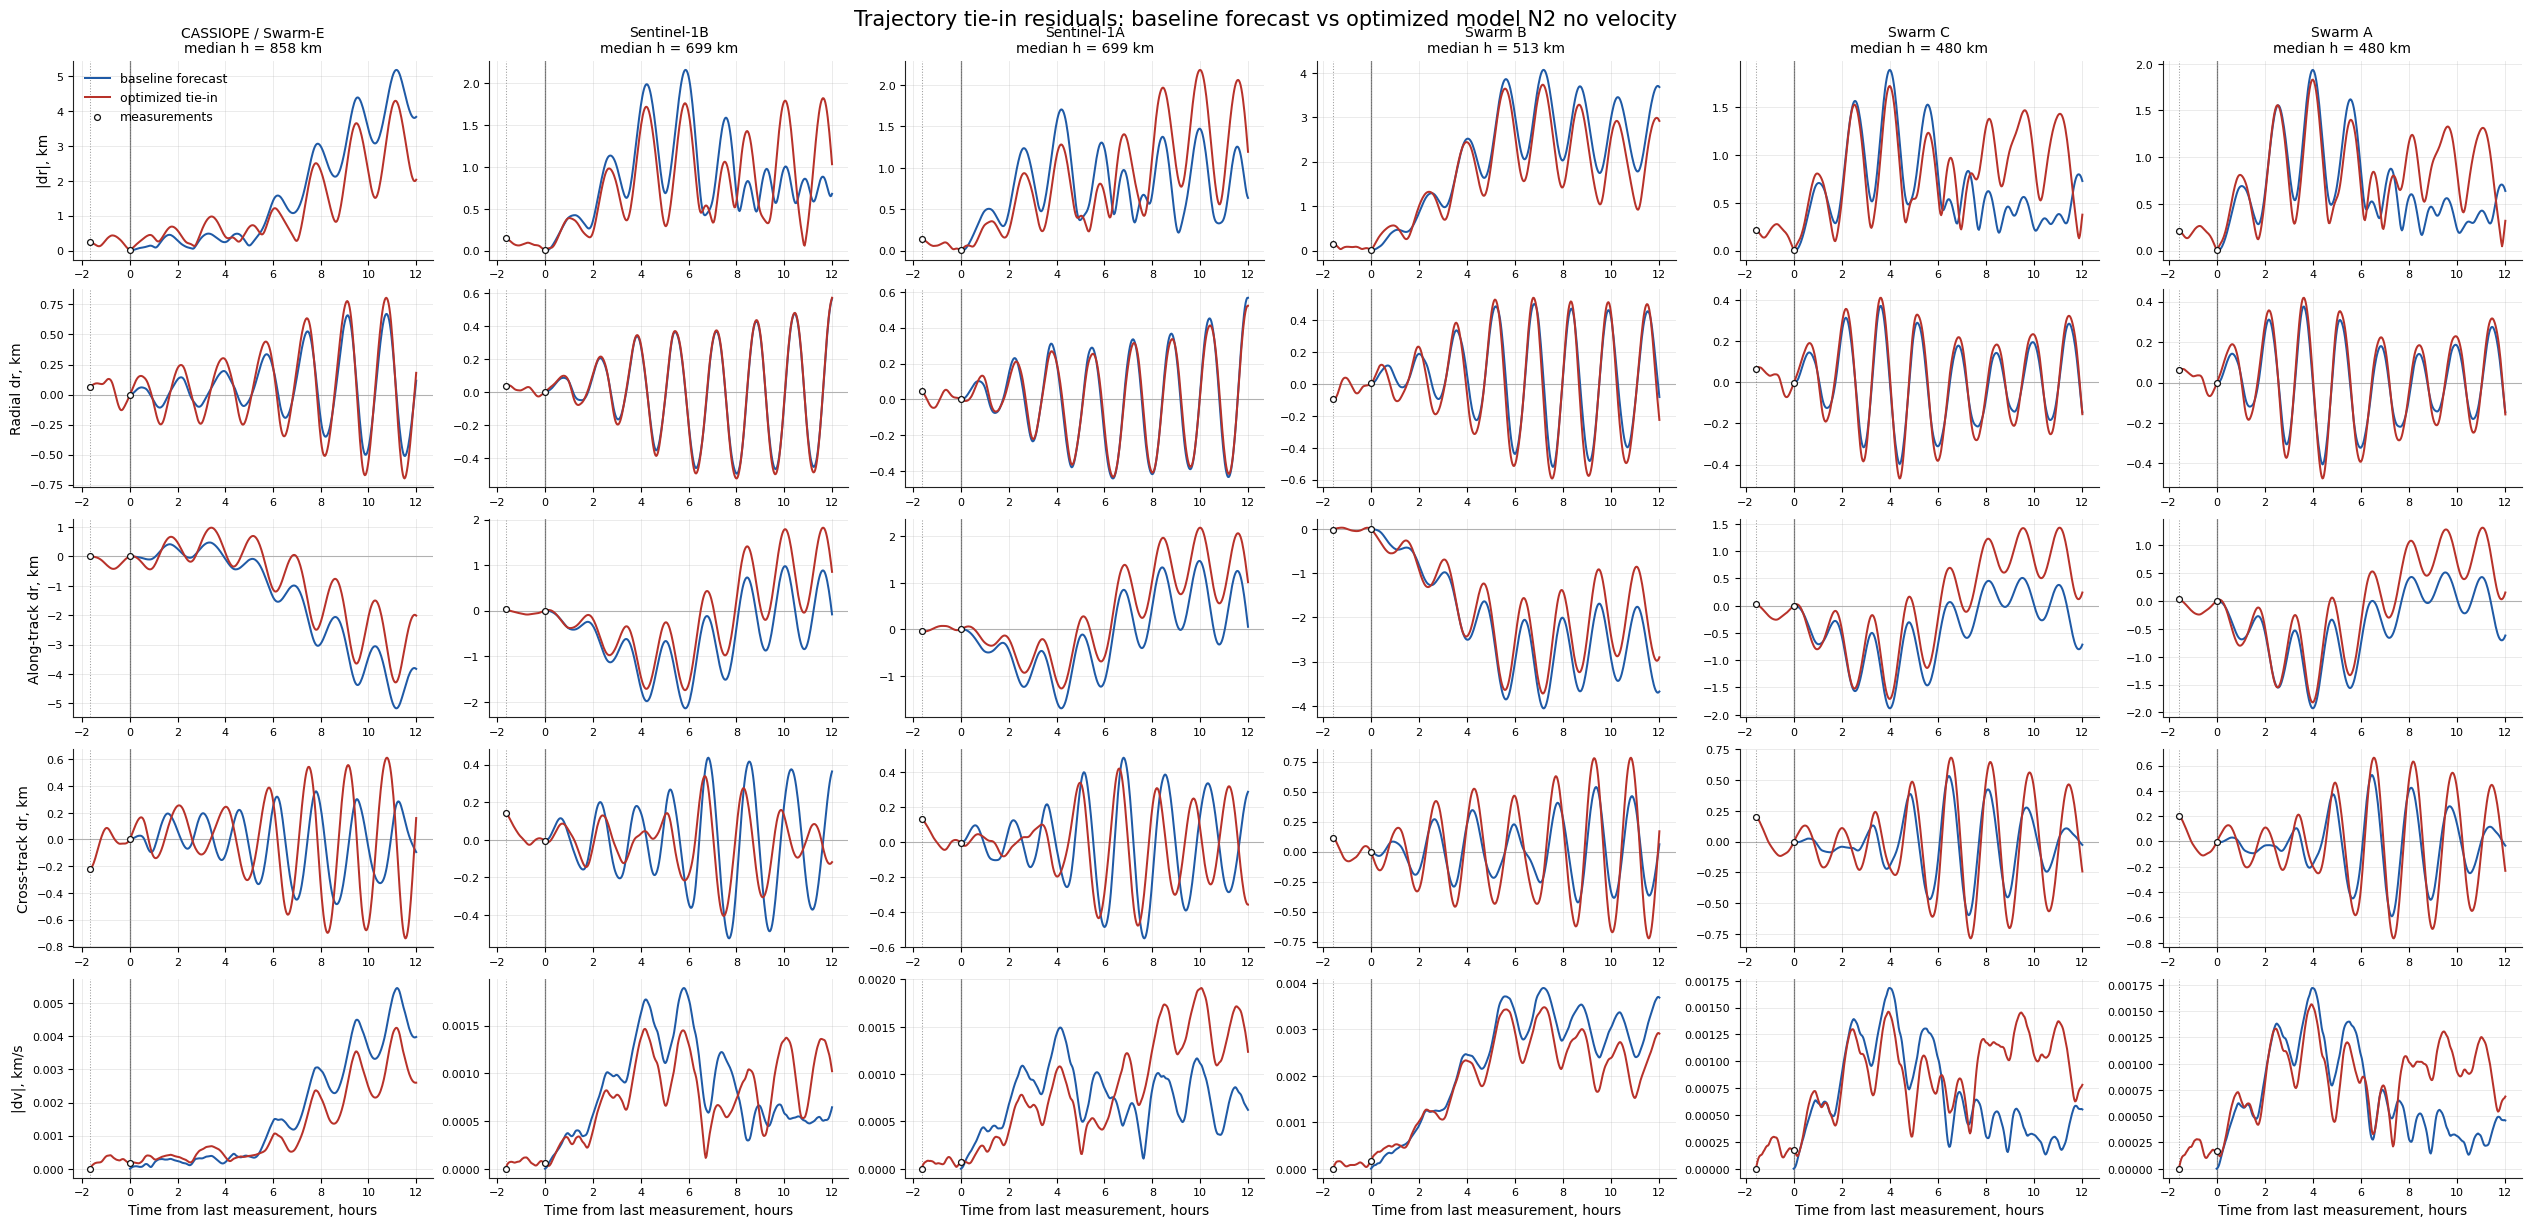

In [8]:
METRIC_ROWS = [
    ('delta_r_norm_km', '|dr|, km'),
    ('delta_radial_km', 'Radial dr, km'),
    ('delta_along_km', 'Along-track dr, km'),
    ('delta_cross_km', 'Cross-track dr, km'),
    ('delta_v_norm_km_s', '|dv|, km/s'),
]

PLOT_STYLE = {
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.edgecolor': '#222222',
    'axes.labelsize': 10,
    'axes.titlesize': 10,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'font.size': 9,
    'legend.fontsize': 9,
}

BASELINE_COLOR = '#1f5aa6'
OPTIMIZED_COLOR = '#b8322a'
MEASUREMENT_COLOR = '#111111'


def plot_tie_in_scenario():
    n_sats = len(REFERENCE_CACHE)
    with plt.rc_context(PLOT_STYLE):
        fig, axes = plt.subplots(
            len(METRIC_ROWS),
            n_sats,
            figsize=(4.2 * n_sats, 12.0),
            sharex=False,
            constrained_layout=True,
        )
        if n_sats == 1:
            axes = axes.reshape(len(METRIC_ROWS), 1)

        for col, item in enumerate(REFERENCE_CACHE):
            baseline = BASELINE_CACHE[item['name']]['residuals']
            optimized = TIE_IN_RESULTS[item['name']]['residuals_plot']
            measurement_hours = item['relative_measurement_hours']
            measurement_residuals = item['measurement_residuals_optimized']
            for row, (metric_key, ylabel) in enumerate(METRIC_ROWS):
                ax = axes[row, col]
                ax.plot(item['forecast_hours'], baseline[metric_key], color=BASELINE_COLOR, lw=1.45, label='baseline forecast')
                ax.plot(
                    item['optimized_plot_hours'],
                    optimized[metric_key],
                    color=OPTIMIZED_COLOR,
                    lw=1.45,
                    label='optimized tie-in',
                )
                for measurement_hour in measurement_hours:
                    ax.axvline(measurement_hour, color=MEASUREMENT_COLOR, lw=0.75, ls=':', alpha=0.42, zorder=0)
                ax.scatter(
                    measurement_hours,
                    measurement_residuals[metric_key],
                    s=18,
                    facecolor='white',
                    edgecolor=MEASUREMENT_COLOR,
                    linewidth=0.9,
                    zorder=4,
                    label='measurements' if row == 0 and col == 0 else None,
                )
                ax.axvline(0.0, color='#333333', lw=0.9, alpha=0.65, zorder=0)
                if metric_key in {'delta_radial_km', 'delta_along_km', 'delta_cross_km'}:
                    ax.axhline(0.0, color='#555555', lw=0.8, alpha=0.45, zorder=0)
                ax.grid(True, alpha=0.25, linewidth=0.7)
                ax.spines['top'].set_visible(False)
                ax.spines['right'].set_visible(False)
                if col == 0:
                    ax.set_ylabel(ylabel)
                if row == len(METRIC_ROWS) - 1:
                    ax.set_xlabel('Time from last measurement, hours')
                if row == 0:
                    title = item['name'] + '\n' + f'median h = {item["median_altitude_km"]:.0f} km'
                    ax.set_title(title)
                if row == 0 and col == 0:
                    ax.legend(frameon=False, loc='upper left')

        fig.suptitle('Trajectory tie-in residuals: baseline forecast vs optimized model N2 no velocity', fontsize=15, y=1.01)
        plt.show()


plot_tie_in_scenario()


## Численная сводка

Эта таблица - компактная проверка воспроизводимости для графика выше.

In [9]:
for item in REFERENCE_CACHE:
    baseline = BASELINE_CACHE[item['name']]['residuals']
    optimized_forecast = TIE_IN_RESULTS[item['name']]['residuals']
    t0_optimized_m = item['measurement_residuals_optimized']['delta_r_norm_km'][-1] * 1000.0
    print(
        f"{item['name']}: "
        f"max |dr| baseline={baseline['delta_r_norm_km'].max():.3f} km, "
        f"optimized={optimized_forecast['delta_r_norm_km'].max():.3f} km; "
        f"final |dr| baseline={baseline['delta_r_norm_km'][-1]:.3f} km, "
        f"optimized={optimized_forecast['delta_r_norm_km'][-1]:.3f} km; "
        f"optimized t0 |dr|={t0_optimized_m:.1f} m; "
        f"max period check error={np.max(item['period_rel_errors']):.2%}"
    )


CASSIOPE / Swarm-E: max |dr| baseline=5.172 km, optimized=4.286 km; final |dr| baseline=3.827 km, optimized=2.029 km; optimized t0 |dr|=5.3 m; max period check error=0.22%
Sentinel-1B: max |dr| baseline=2.160 km, optimized=1.822 km; final |dr| baseline=0.678 km, optimized=1.033 km; optimized t0 |dr|=4.6 m; max period check error=0.36%
Sentinel-1A: max |dr| baseline=1.706 km, optimized=2.183 km; final |dr| baseline=0.637 km, optimized=1.193 km; optimized t0 |dr|=5.0 m; max period check error=0.19%
Swarm B: max |dr| baseline=4.064 km, optimized=3.731 km; final |dr| baseline=3.677 km, optimized=2.916 km; optimized t0 |dr|=5.7 m; max period check error=0.41%
Swarm C: max |dr| baseline=1.894 km, optimized=1.725 km; final |dr| baseline=0.729 km, optimized=0.376 km; optimized t0 |dr|=7.1 m; max period check error=0.25%
Swarm A: max |dr| baseline=1.934 km, optimized=1.830 km; final |dr| baseline=0.638 km, optimized=0.319 km; optimized t0 |dr|=7.2 m; max period check error=0.25%


## Замечания и ограничения

* Выбранная линия слежения - только эвристика отбора отсчётов; невязка широты/долготы не включается в функцию потерь.
* Исторические состояния не интерполируются. Детектор пересечения выбирает ближайший исходный исторический отсчёт, поэтому ошибка времени события ограничена исходным интервалом дискретизации.
* Оптимизируемые параметры космического аппарата - баллистические коэффициенты, а не независимые масса, площадь, Cd и Cr. Это устраняет проблему идентифицируемости, потому что текущие уравнения сил зависят от `Cd*A/m` и `Cr*A/m`.
* Сигмы наблюдений взвешивают невязки измерений вдоль одной непрерывной траектории. `LAST_MEASUREMENT_OBSERVATION_SCALE` всё ещё может дать последнему измерению больший вес, но больше не перезапускает оптимизированную траекторию при `t = 0`.
* Возмущения J2 / EGM, ускорения третьих тел Солнце/Луна, релятивистская поправка и приливы твёрдой Земли при включении оптимизируются как безразмерные масштабные коэффициенты. Центральная сферическая гравитация Земли не масштабируется.

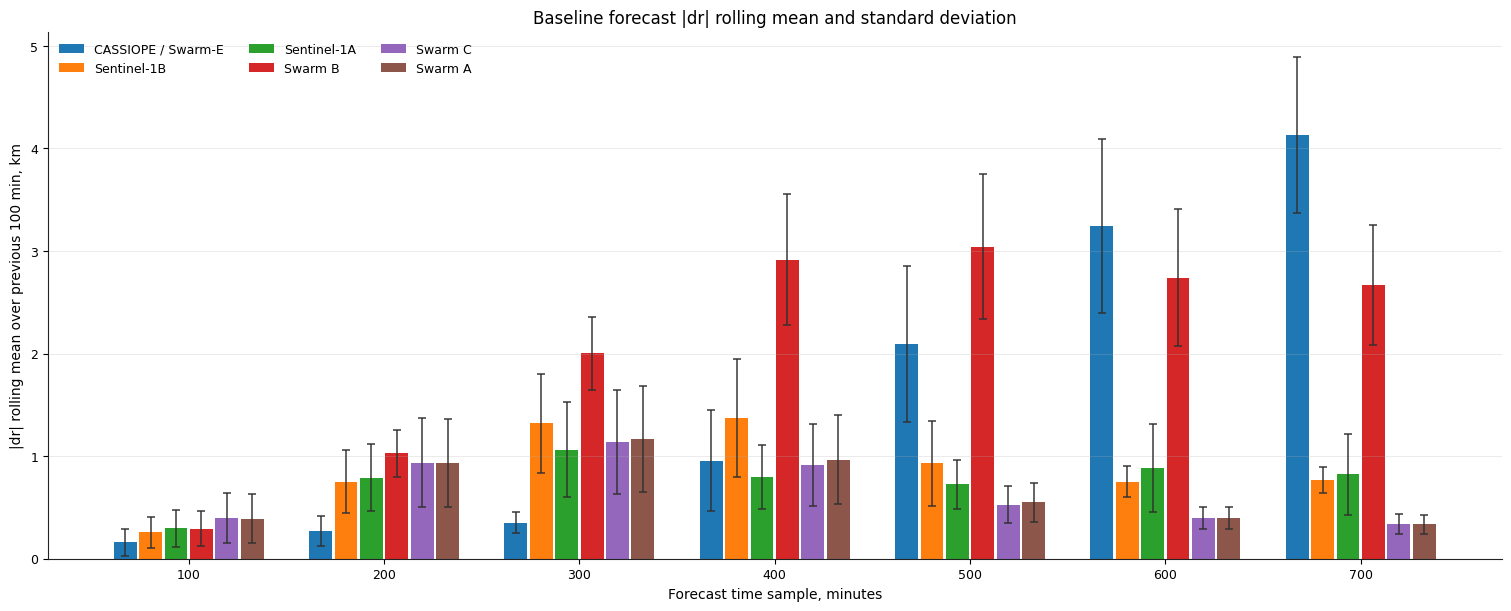

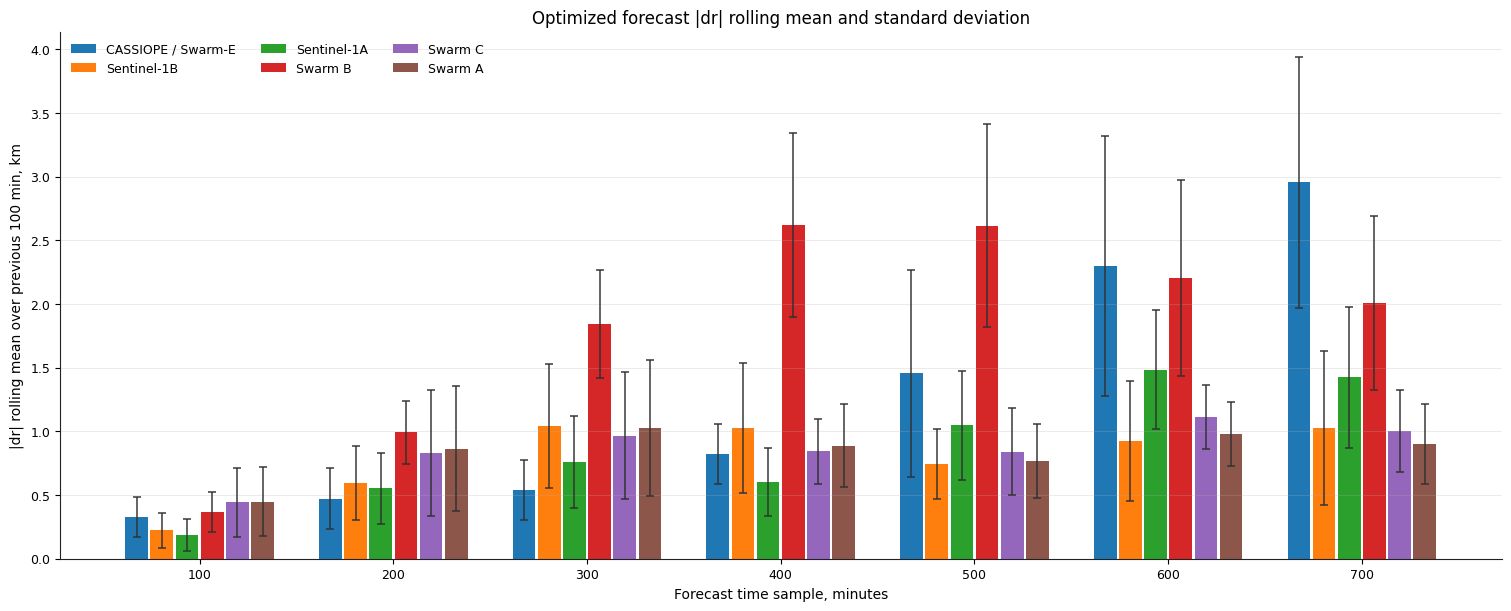

In [10]:
ROLLING_WINDOW_MINUTES = 100.0
GROUP_STEP_MINUTES = 100.0


def rolling_mean_std_at_targets(t_minutes, values, target_minutes, window_minutes=ROLLING_WINDOW_MINUTES):
    """Return mean and std over [target - window_minutes, target] for each target time."""
    t_minutes = np.asarray(t_minutes, dtype=float)
    values = np.asarray(values, dtype=float)
    target_minutes = np.asarray(target_minutes, dtype=float)
    means = np.full(target_minutes.shape, np.nan, dtype=float)
    stds = np.full(target_minutes.shape, np.nan, dtype=float)

    for index, t_current in enumerate(target_minutes):
        start_index = np.searchsorted(t_minutes, t_current - window_minutes, side='left')
        end_index = np.searchsorted(t_minutes, t_current, side='right')
        window = values[start_index:end_index]
        finite_window = window[np.isfinite(window)]
        if finite_window.size == 0:
            continue
        means[index] = finite_window.mean()
        stds[index] = finite_window.std(ddof=0)

    return means, stds


satellite_colors = {
    'CASSIOPE / Swarm-E': '#1f77b4',
    'Sentinel-1B': '#ff7f0e',
    'Sentinel-1A': '#2ca02c',
    'Swarm B': '#d62728',
    'Swarm C': '#9467bd',
    'Swarm A': '#8c564b',
}


def dr_series_for_rolling_bars(item, scenario):
    """Return forecast time in minutes and |dr| in km for a plotting scenario."""
    if scenario == 'baseline':
        t_minutes = np.asarray(item['forecast_hours'], dtype=float) * 60.0
        dr_km = BASELINE_CACHE[item['name']]['residuals']['delta_r_norm_km']
    elif scenario == 'optimized':
        result = TIE_IN_RESULTS[item['name']]
        t_minutes = (np.asarray(result['model_times_unix'], dtype=float) - float(item['t0_epoch'].unix)) / 60.0
        dr_km = result['residuals']['delta_r_norm_km']
    else:
        raise ValueError(f'Unsupported scenario: {scenario}')

    return t_minutes, np.asarray(dr_km, dtype=float)


def plot_rolling_dr_bars(scenario, title):
    n_sats = len(REFERENCE_CACHE)
    series = [dr_series_for_rolling_bars(item, scenario) for item in REFERENCE_CACHE]
    max_t_minutes = min(float(np.nanmax(t_minutes)) for t_minutes, _ in series)
    target_minutes = np.arange(GROUP_STEP_MINUTES, max_t_minutes + 0.5 * GROUP_STEP_MINUTES, GROUP_STEP_MINUTES)
    bar_group_width_minutes = 0.78 * GROUP_STEP_MINUTES
    bar_width_minutes = bar_group_width_minutes / max(n_sats, 1)
    bar_offsets = (np.arange(n_sats) - (n_sats - 1) / 2.0) * bar_width_minutes

    style = dict(PLOT_STYLE)
    style.update({'axes.titlesize': 12, 'xtick.labelsize': 9, 'ytick.labelsize': 9, 'font.size': 10})
    with plt.rc_context(style):
        fig, ax = plt.subplots(figsize=(15, 6), constrained_layout=True)

        for sat_index, (item, (t_minutes, dr_km)) in enumerate(zip(REFERENCE_CACHE, series)):
            rolling_mean_km, rolling_std_km = rolling_mean_std_at_targets(
                t_minutes,
                dr_km,
                target_minutes,
                window_minutes=ROLLING_WINDOW_MINUTES,
            )
            color = satellite_colors.get(item['name'], f'C{sat_index}')
            ax.bar(
                target_minutes + bar_offsets[sat_index],
                rolling_mean_km,
                width=bar_width_minutes * 0.9,
                yerr=rolling_std_km,
                color=color,
                alpha=1.0,
                ecolor='#303030',
                error_kw={'elinewidth': 1.4, 'capthick': 1.4, 'alpha': 0.75, 'capsize': 3.0},
                linewidth=0,
                label=item['name'],
            )

        ax.set_xticks(target_minutes)
        ax.set_xlabel('Forecast time sample, minutes')
        ax.set_ylabel('|dr| rolling mean over previous 100 min, km')
        ax.set_title(title)
        ax.grid(True, axis='y', alpha=0.25, linewidth=0.7)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.legend(ncol=3, frameon=False, loc='upper left')

        plt.show()


plot_rolling_dr_bars('baseline', 'Baseline forecast |dr| rolling mean and standard deviation')
plot_rolling_dr_bars('optimized', 'Optimized forecast |dr| rolling mean and standard deviation')
